In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from brisque.brisque import BRISQUE

In [7]:
def load_image(path):
    img = cv2.imread(path)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def detect_blue_mask(image, mask_region):
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    
    lower_blue = np.array([90, 50, 50])
    upper_blue = np.array([140, 255, 255])
    
    mask = cv2.inRange(hsv, lower_blue, upper_blue)

    mask_of_region = np.zeros(mask.shape, dtype=np.uint8)
    y1, x1, y2, x2 = mask_region
    mask_of_region[y1:y2, x1:x2] = mask[y1:y2, x1:x2]
    return mask_of_region

def inpaint_image(image, mask, method="telea", radius=3):
    if method == "telea":
        flag = cv2.INPAINT_TELEA
    else:
        flag = cv2.INPAINT_NS
        
    return cv2.inpaint(image, mask, radius, flag)

def pipeline(image_path):
    image = load_image(image_path)

    mask_region = (50, 200, image.shape[0]-100, image.shape[1]-200)
    mask = detect_blue_mask(image, mask_region)
    
    result_telea = inpaint_image(image, mask, method="telea", radius=3)
    result_ns = inpaint_image(image, mask, method="ns", radius=3)

    score_telea = cv2.quality.QualityBRISQUE_compute(result_telea, "brisque_model.yml", "brisque_range.yml")
    score_ns = cv2.quality.QualityBRISQUE_compute(result_ns, "brisque_model.yml", "brisque_range.yml")
    print(f"BRISQUE Score (telea): {score_telea}")
    print(f"BRISQUE Score (ns): {score_ns}")
    
    plt.figure(figsize=(16,12))
    
    plt.subplot(2,2,1)
    plt.title(f"Obraz - {image_path}")
    plt.imshow(image)
    
    plt.subplot(2,2,2)
    plt.title("Maska (niebieskie)")
    plt.imshow(mask, cmap='gray')
    
    plt.subplot(2,2,3)
    plt.title("Inpainting - telea")
    plt.imshow(result_telea)

    plt.subplot(2,2,4)
    plt.title("Inpainting - ns")
    plt.imshow(result_ns)
    
    plt.show()

BRISQUE Score (telea): (41.2249755859375, 0.0, 0.0, 0.0)
BRISQUE Score (ns): (41.26068878173828, 0.0, 0.0, 0.0)


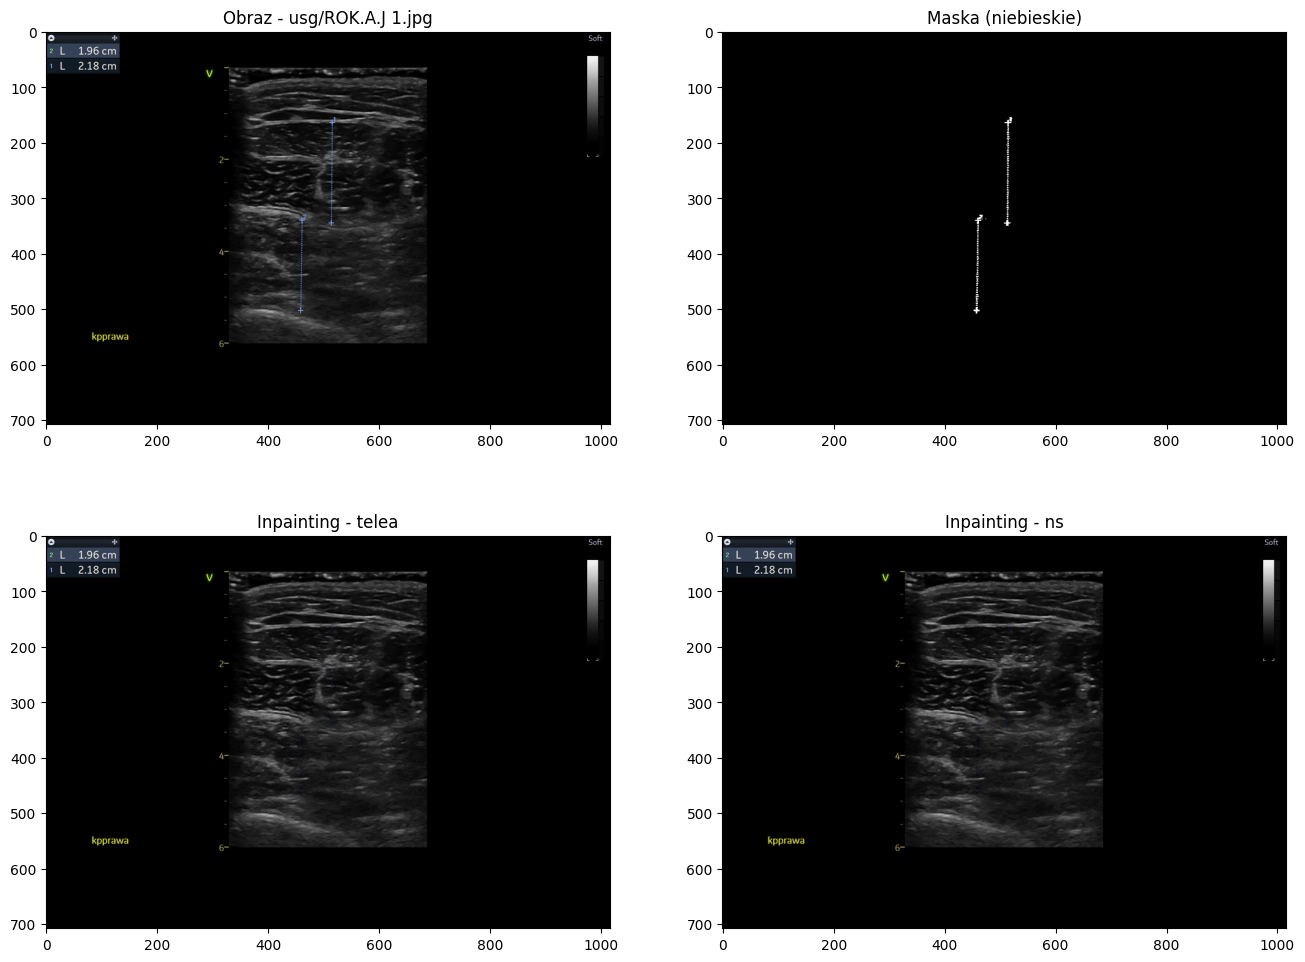

BRISQUE Score (telea): (44.2216796875, 0.0, 0.0, 0.0)
BRISQUE Score (ns): (44.37751770019531, 0.0, 0.0, 0.0)


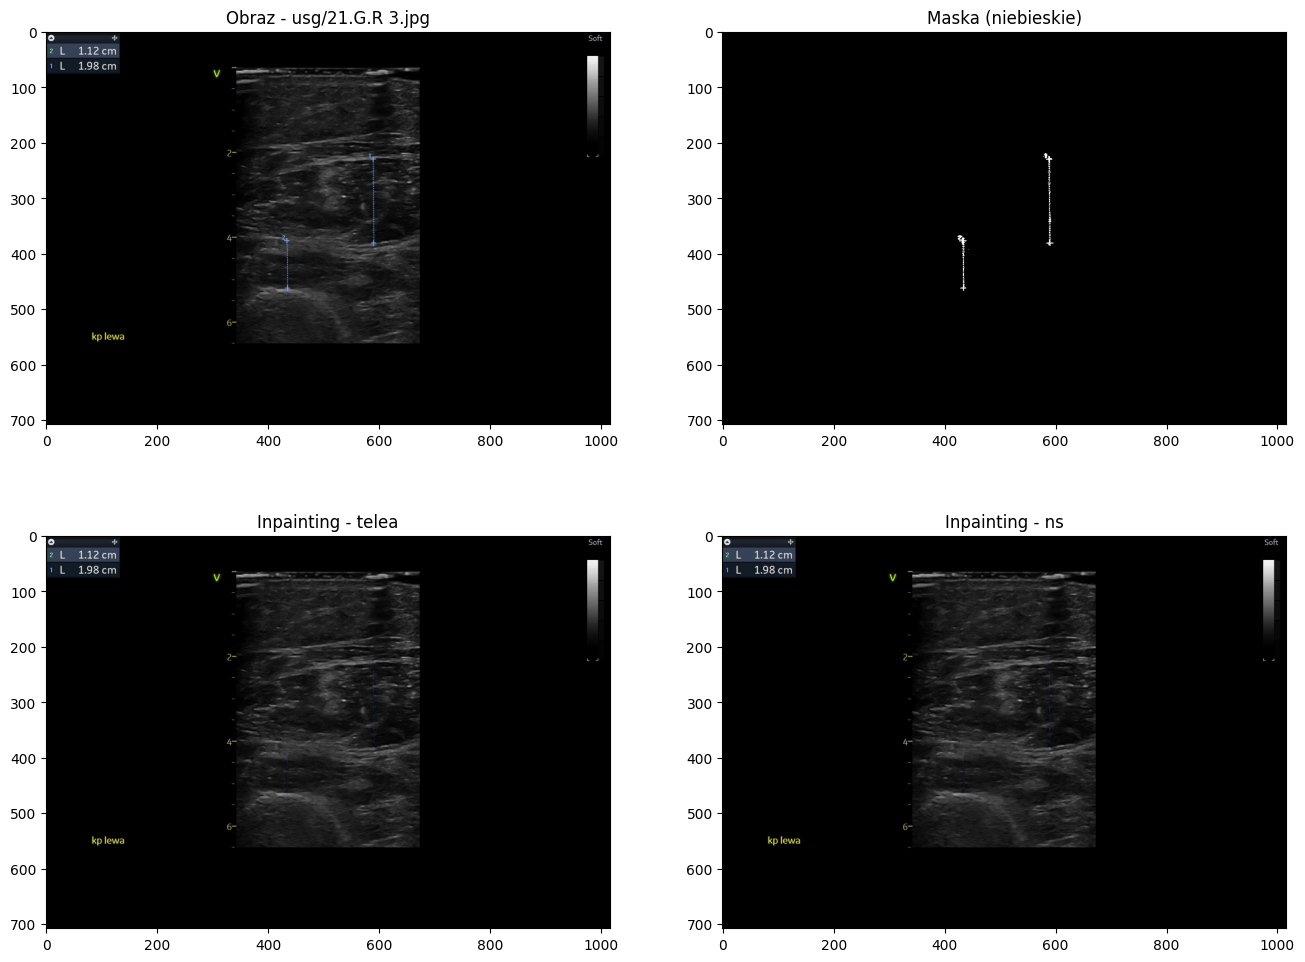

BRISQUE Score (telea): (43.03938674926758, 0.0, 0.0, 0.0)
BRISQUE Score (ns): (43.10411071777344, 0.0, 0.0, 0.0)


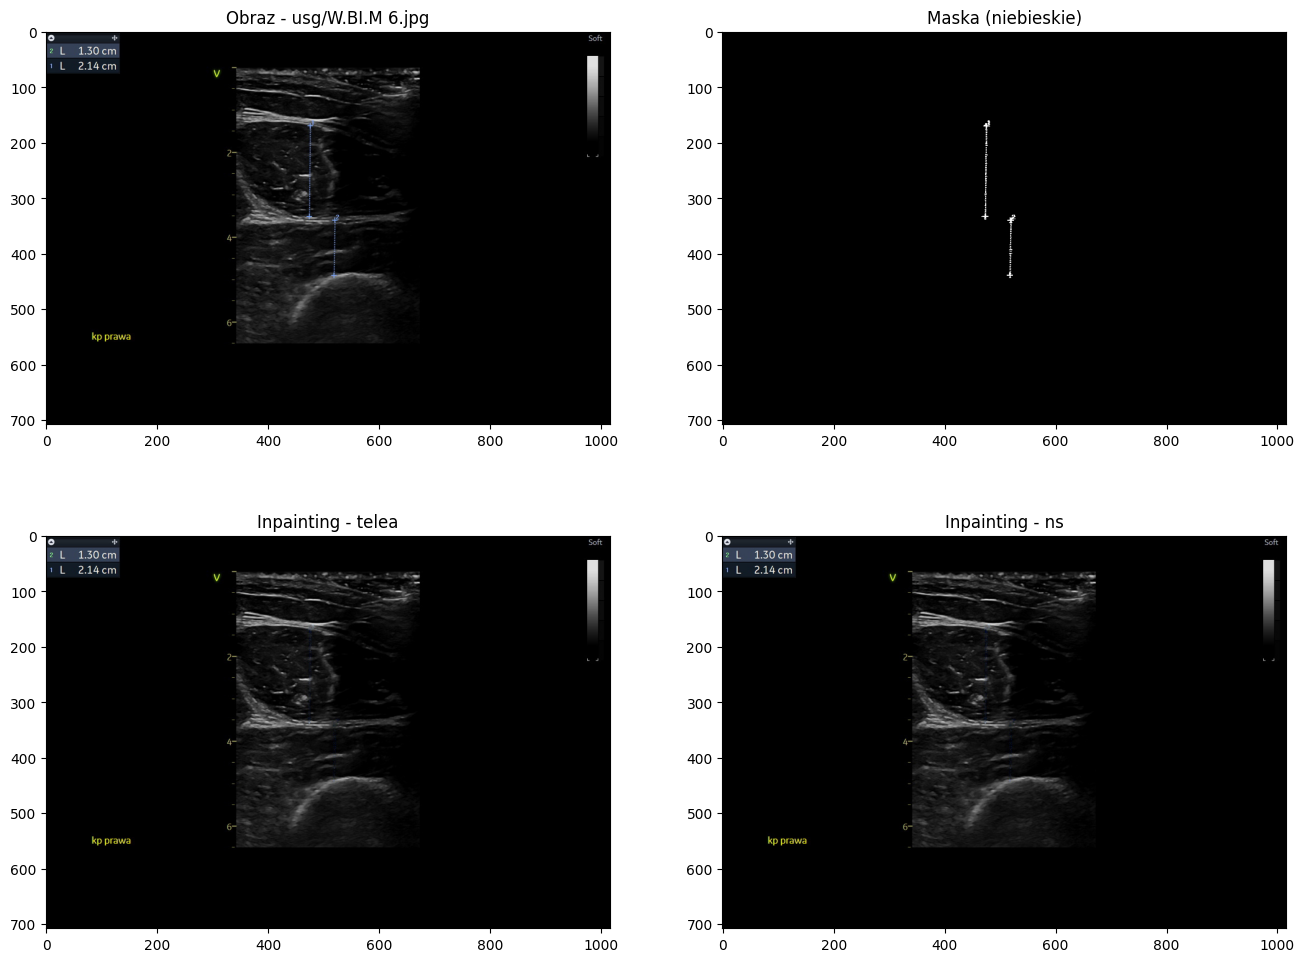

BRISQUE Score (telea): (35.63894271850586, 0.0, 0.0, 0.0)
BRISQUE Score (ns): (35.714271545410156, 0.0, 0.0, 0.0)


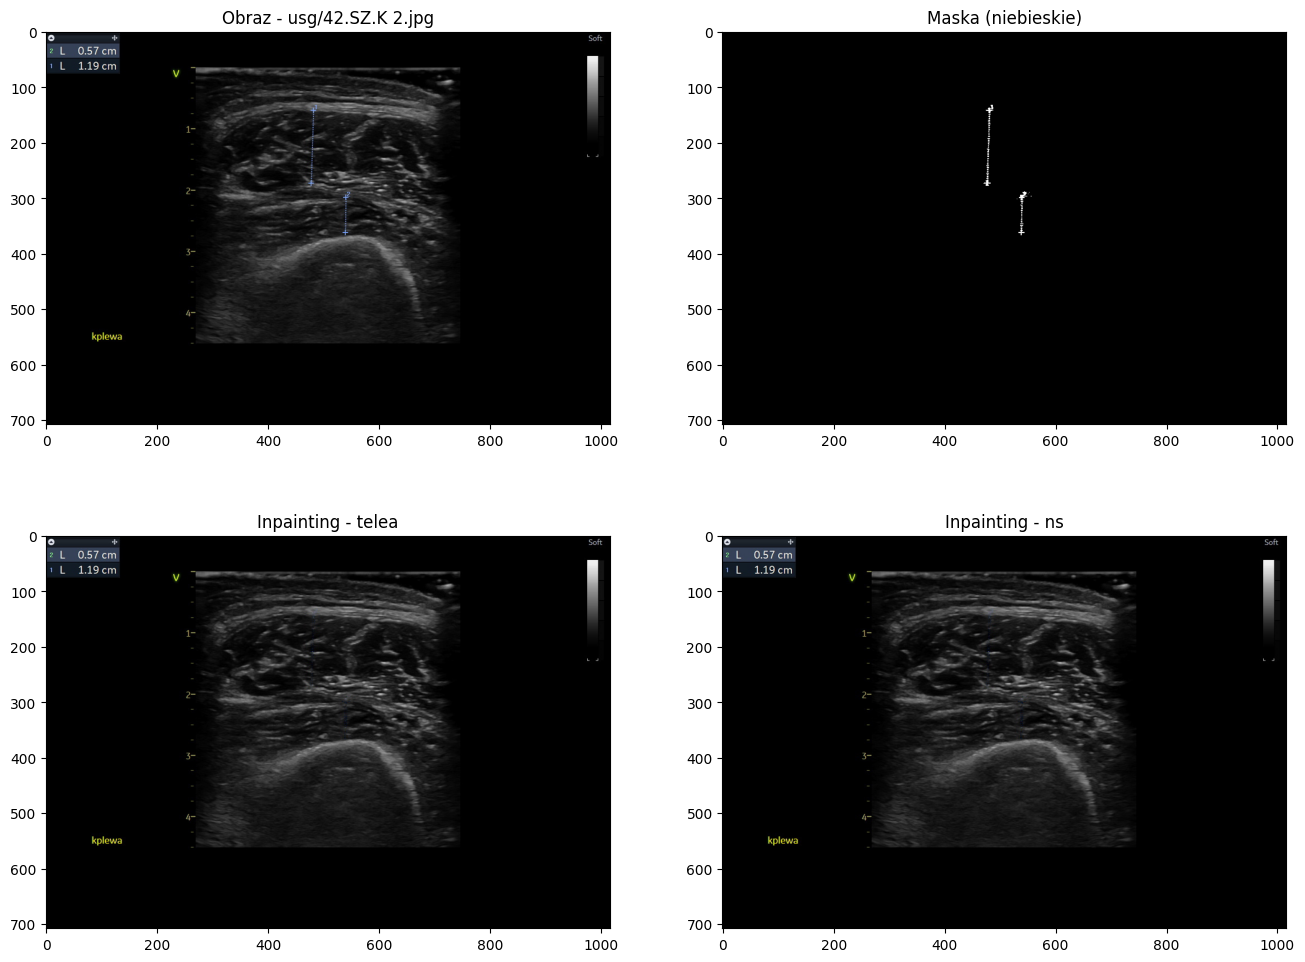

BRISQUE Score (telea): (38.95432662963867, 0.0, 0.0, 0.0)
BRISQUE Score (ns): (39.01179504394531, 0.0, 0.0, 0.0)


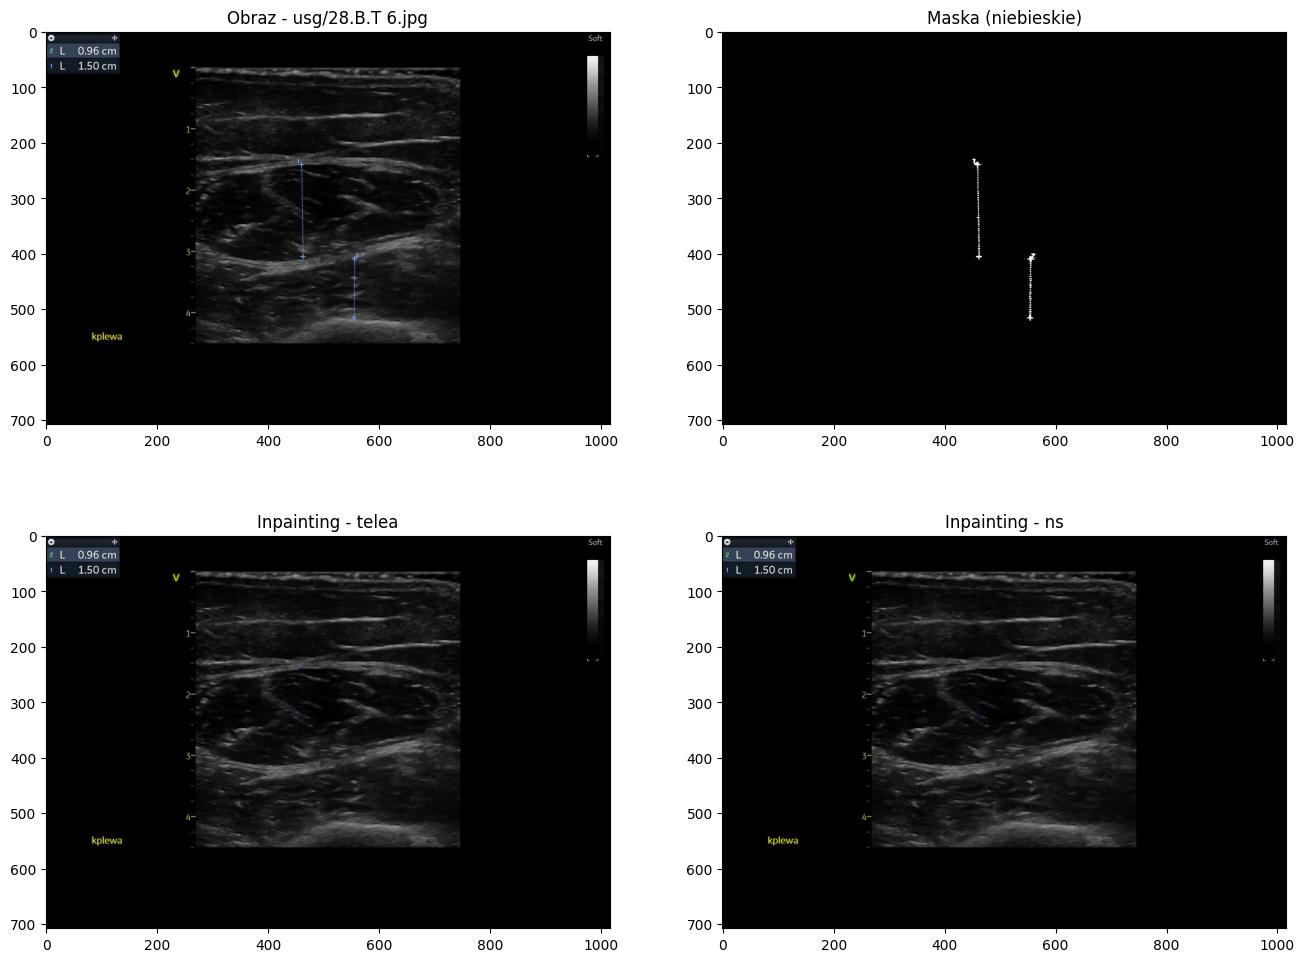

BRISQUE Score (telea): (38.203338623046875, 0.0, 0.0, 0.0)
BRISQUE Score (ns): (38.331390380859375, 0.0, 0.0, 0.0)


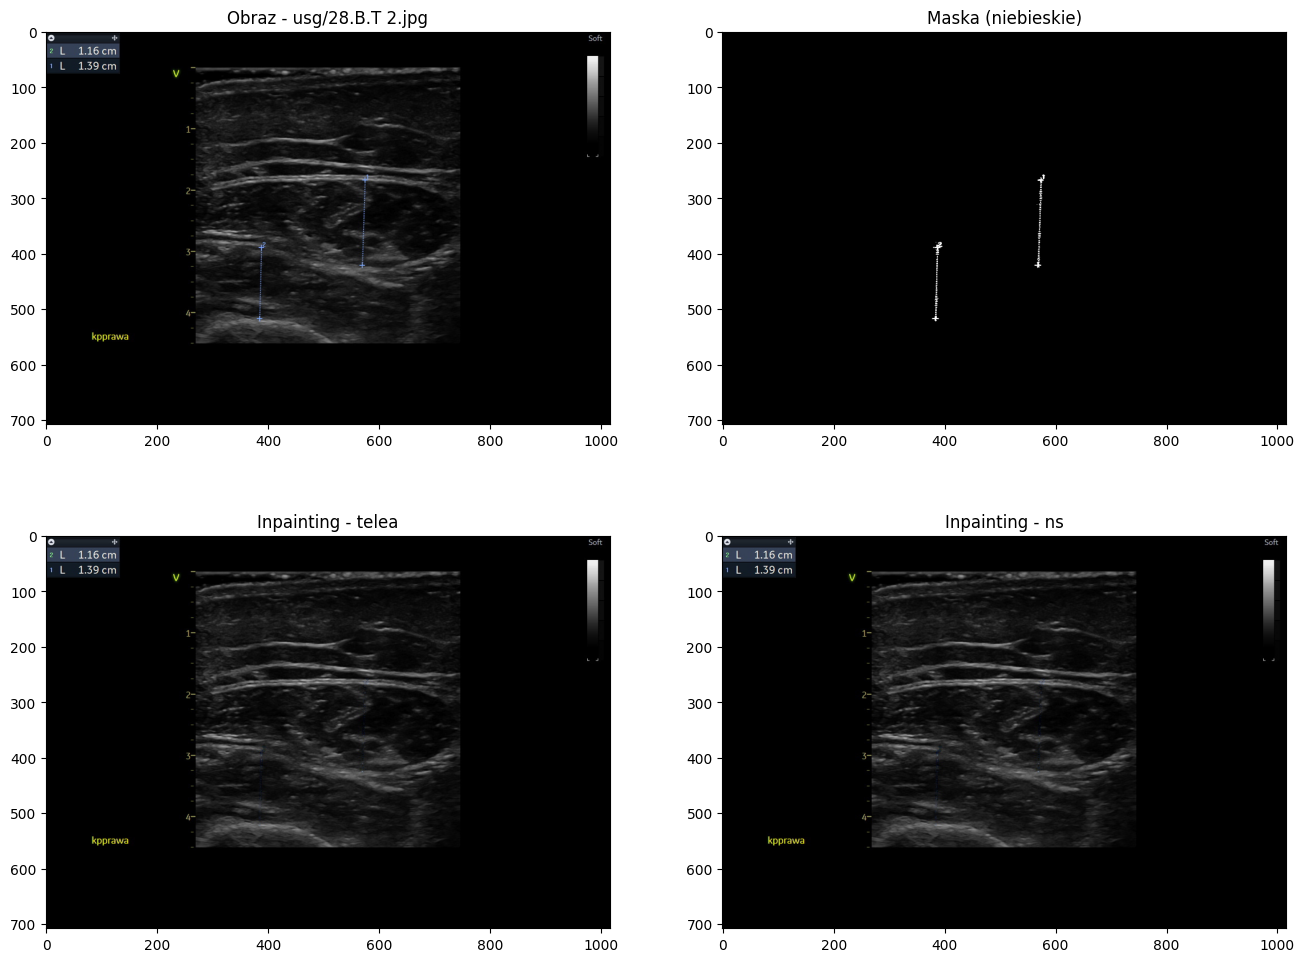

BRISQUE Score (telea): (44.996864318847656, 0.0, 0.0, 0.0)
BRISQUE Score (ns): (45.13804626464844, 0.0, 0.0, 0.0)


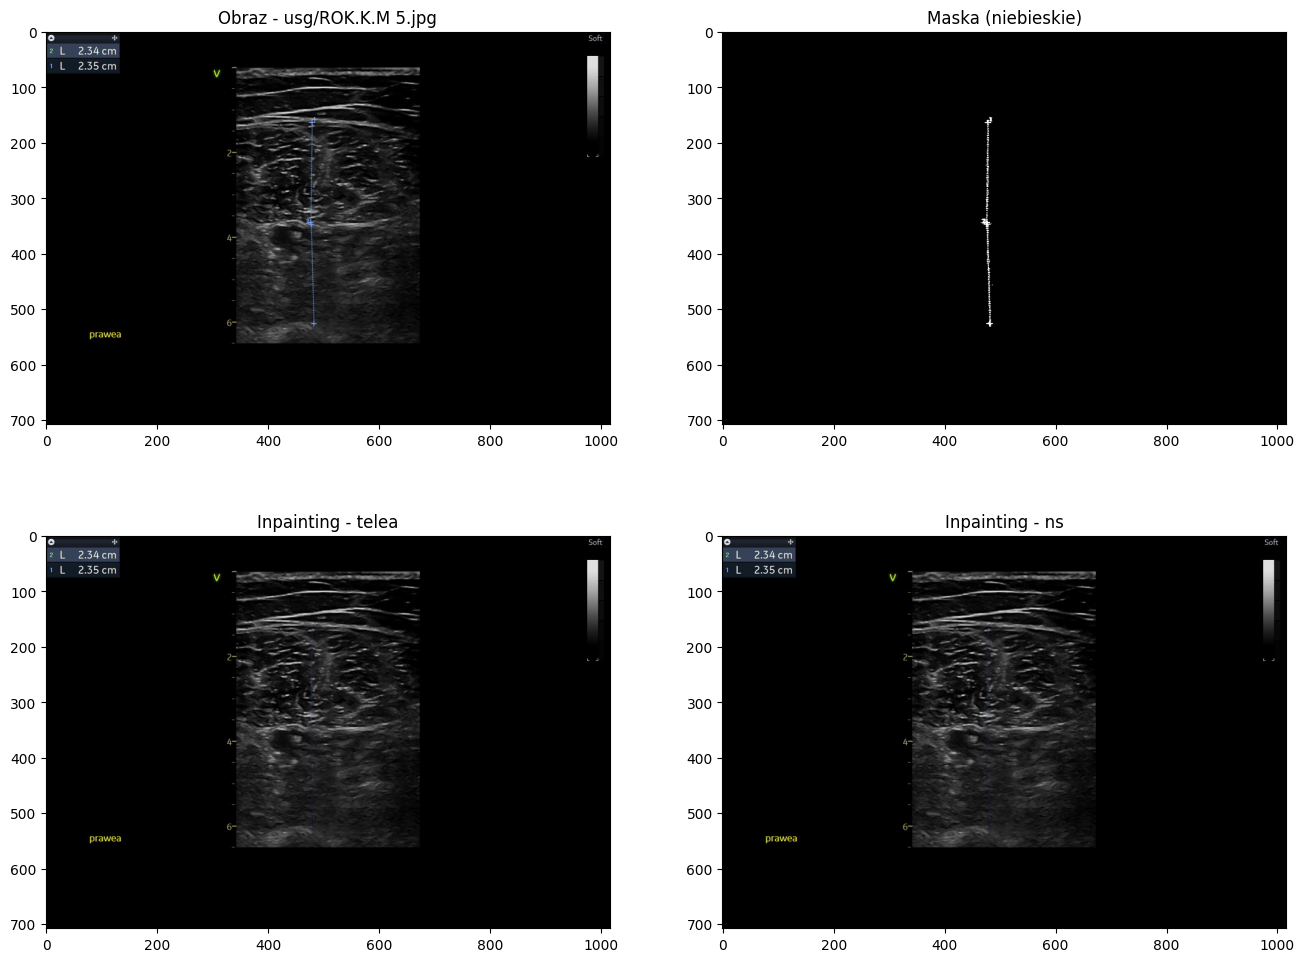

BRISQUE Score (telea): (53.567440032958984, 0.0, 0.0, 0.0)
BRISQUE Score (ns): (53.68438720703125, 0.0, 0.0, 0.0)


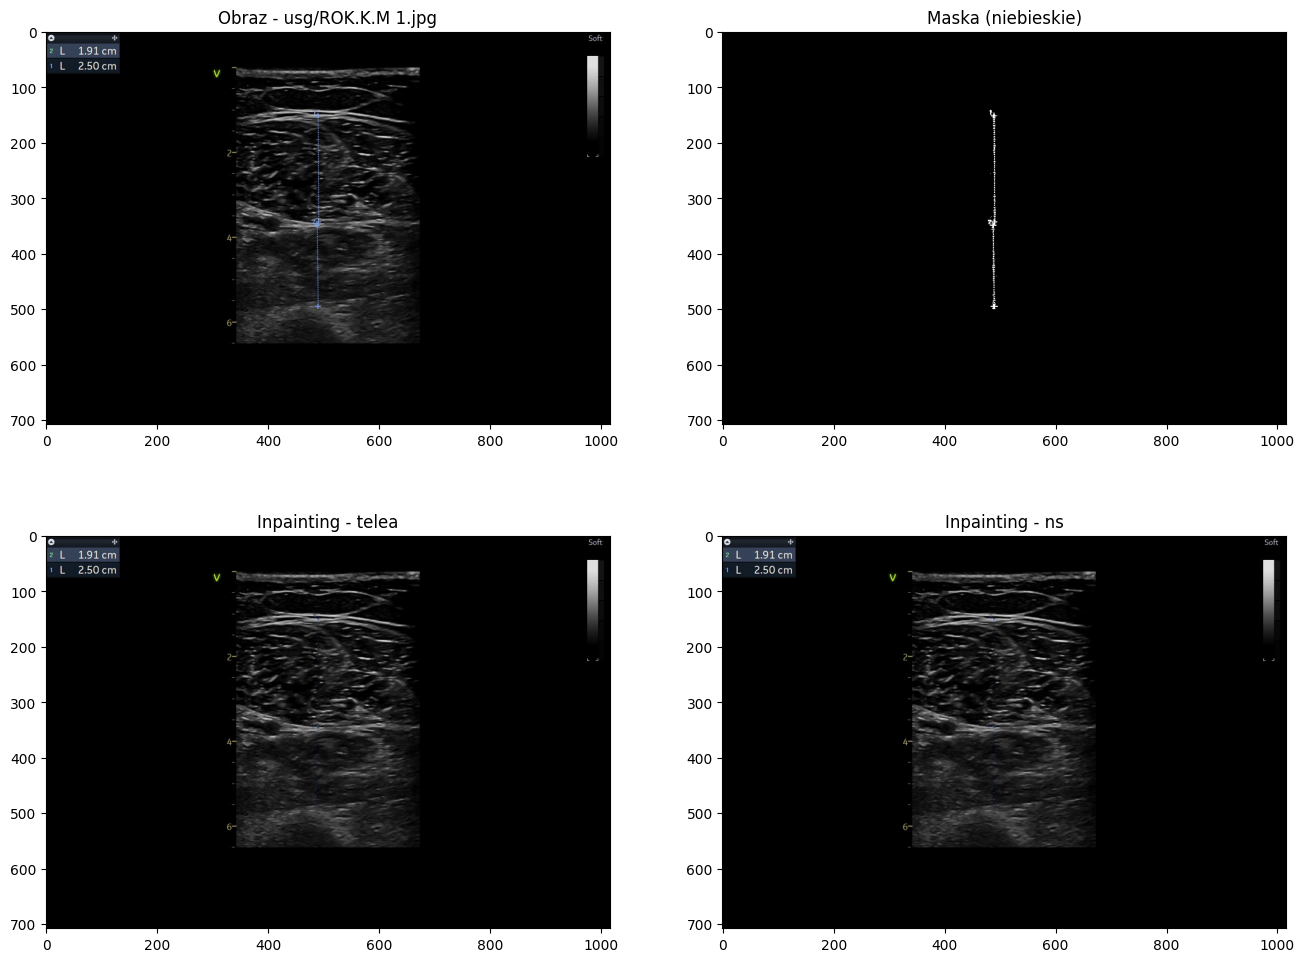

BRISQUE Score (telea): (40.136470794677734, 0.0, 0.0, 0.0)
BRISQUE Score (ns): (40.22601318359375, 0.0, 0.0, 0.0)


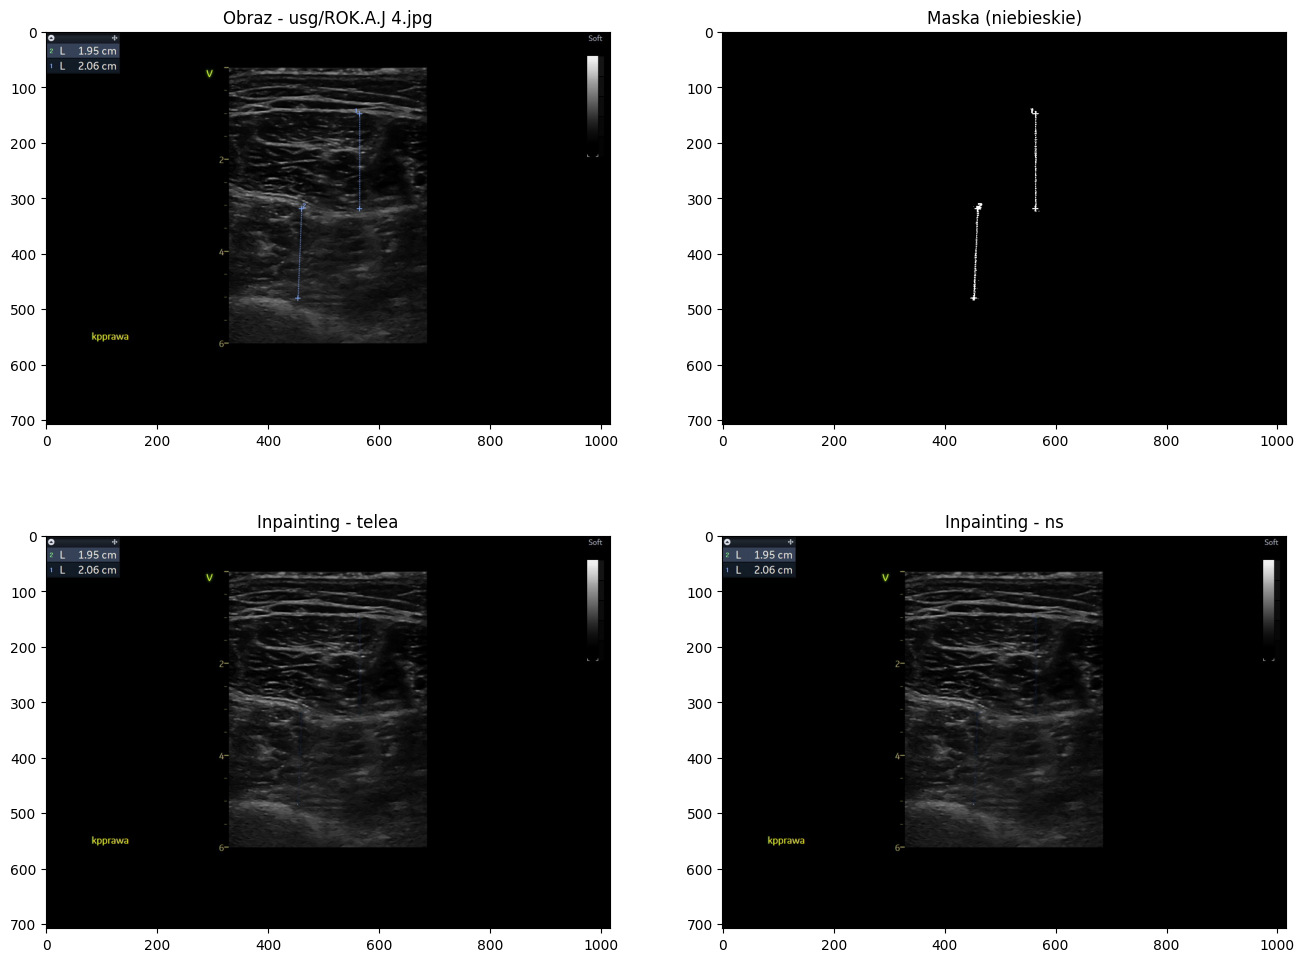

BRISQUE Score (telea): (42.7723503112793, 0.0, 0.0, 0.0)
BRISQUE Score (ns): (42.81660842895508, 0.0, 0.0, 0.0)


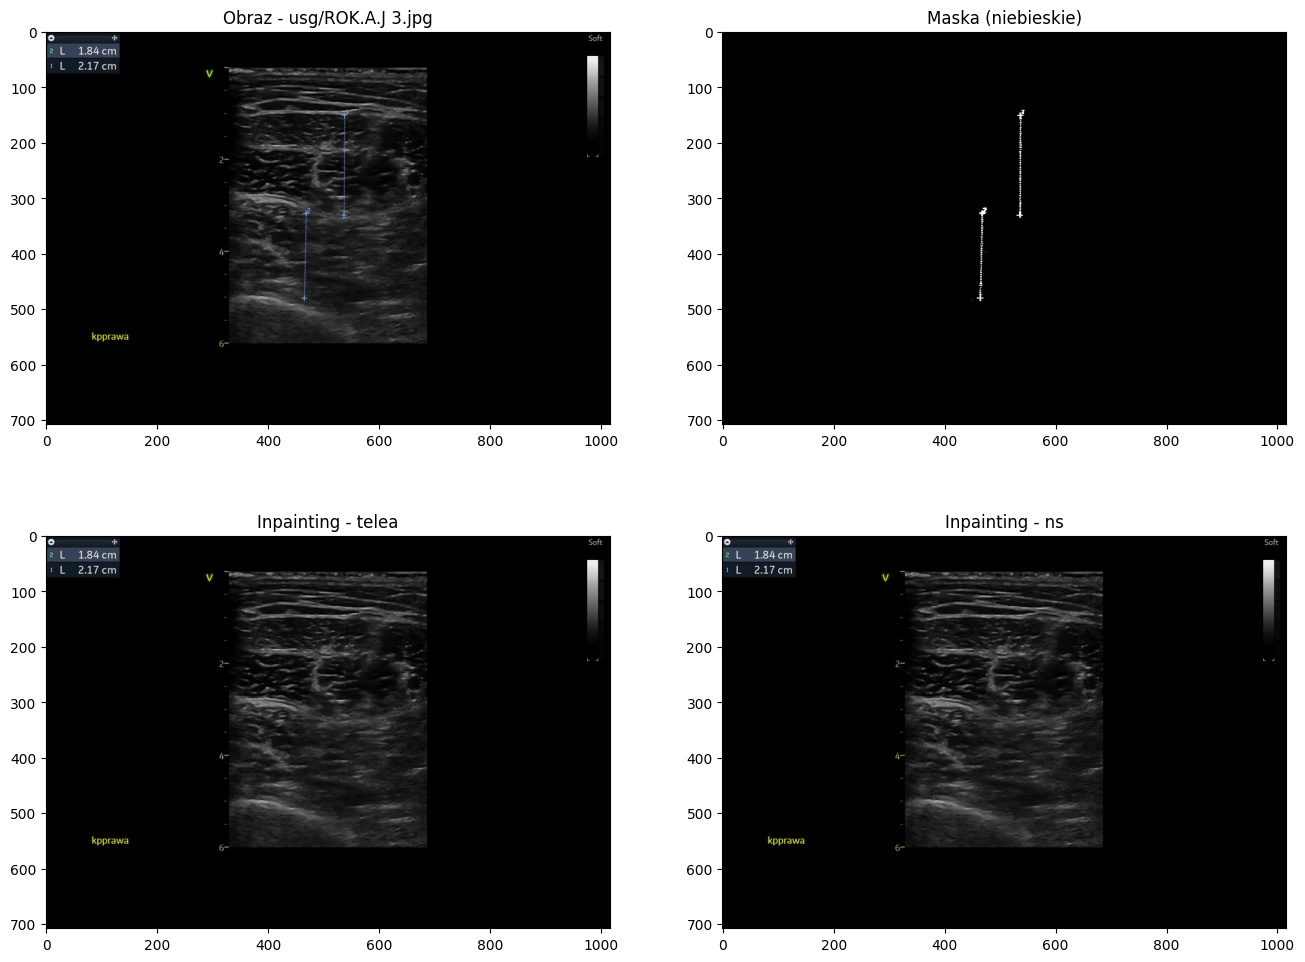

BRISQUE Score (telea): (40.76249313354492, 0.0, 0.0, 0.0)
BRISQUE Score (ns): (40.77360153198242, 0.0, 0.0, 0.0)


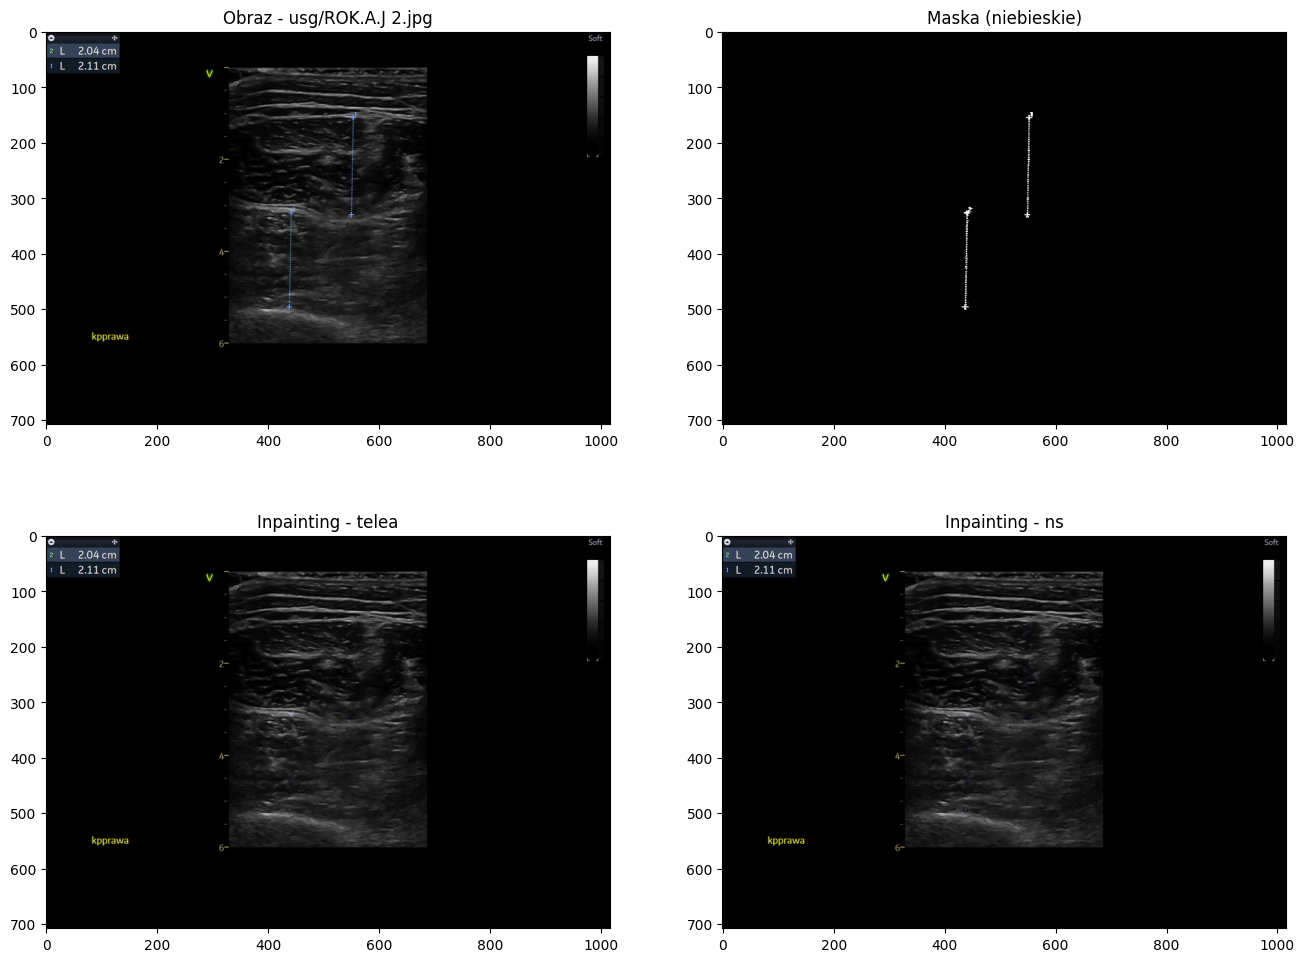

In [8]:
dir_path = "usg"
for file in os.listdir(dir_path):
    if file.endswith(".jpg"):
        path = os.path.join(dir_path, file)
        pipeline(path)